<a href="https://colab.research.google.com/github/tranquoctruong2503/THUCHANH_DEEPLEARNING/blob/main/ThucHanhBuoi04_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AUTOENCODER

In [ ]:
# Cai thu vien
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
from keras import regularizers


In [ ]:
# Cai dataset
(x_train, _),(x_test, _) = mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 784)
(10000, 784)


In [ ]:
# Mo hinh Autoencoder
encoding_dim = 32

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
# Huan luyen mo hinh
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=100, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0093 - loss: 0.2730 - val_accuracy: 0.0122 - val_loss: 0.1894
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0110 - loss: 0.1709 - val_accuracy: 0.0126 - val_loss: 0.1538
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0102 - loss: 0.1446 - val_accuracy: 0.0102 - val_loss: 0.1343
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0096 - loss: 0.1286 - val_accuracy: 0.0093 - val_loss: 0.1214
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0097 - loss: 0.1180 - val_accuracy: 0.0095 - val_loss: 0.1127
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0103 - loss: 0.1109 - val_accuracy: 0.0114 - val_loss: 0.1068
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0106 - loss: 0.1060 - val_accuracy: 0.0103 - val_loss: 0.1027
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0110 - loss: 0.1024 - 

In [ ]:
# Loai anh su dung
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


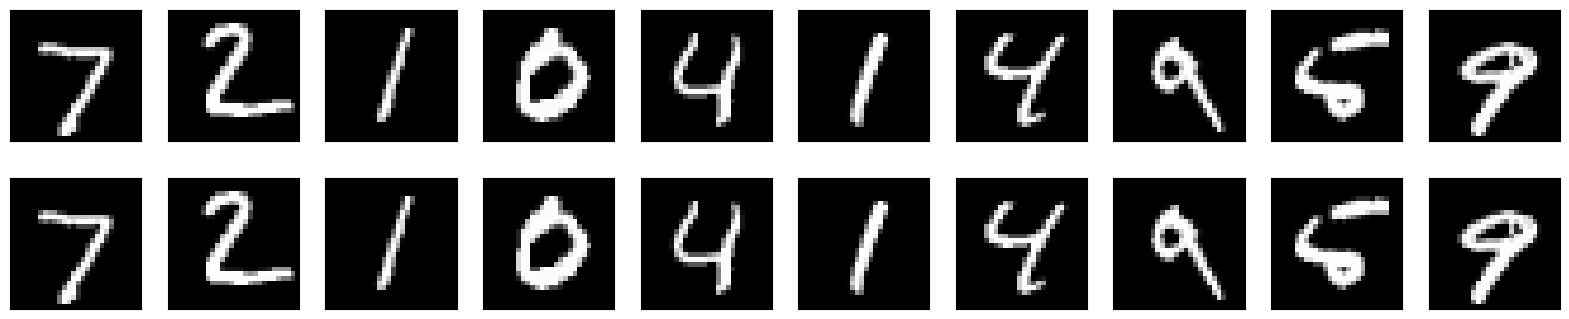

In [ ]:
# Hien thi anh
import matplotlib.pyplot as plt

n= 10
plt.figure(figsize=(20,4))
for i in range(n):
  ax = plt.subplot(2, n, i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

CẢI TIẾN AUTOENCODER

In [ ]:
# Them L1
# encoding_dim = 32

# input_img = keras.Input(shape=(784,))

# encoded = layers.Dense(encoding_dim,activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)

# decoded = layers.Dense(784, activation='sigmoid')(encoded)

# autoencoder = keras.Model(input_img, decoded)

# encoder = keras.Model(input_img, encoded)
# encoded_input = keras.Input(shape=(encoding_dim,))
# decoder_layer = autoencoder.layers[-1]
# decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
# Them layers
# encoding_dim = 32

# input_img = keras.Input(shape=(784,))

# encoded = layers.Dense(128, activation='relu')(input_img)
# encoded = layers.Dense(64, activation='relu')(encoded)
# encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# decoded = layers.Dense(784, activation='sigmoid')(encoded)

# autoencoder = keras.Model(input_img, decoded)

# encoder = keras.Model(input_img, encoded)

# encoded_input = keras.Input(shape=(32,))
# decoder_layer = autoencoder.layers[-1]
# decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
# Huan luyen
# autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# autoencoder.fit(x_train, x_train, epochs=100, batch_size=256,verbose=1, shuffle=True, validation_data=(x_test, x_test))

BÀI TẬP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.datasets import cifar10

In [ ]:
print("--- Đang tải dữ liệu CIFAR-10 ---")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Kích thước tập huấn luyện (Train shape): {x_train.shape}")
print(f"Kích thước tập kiểm tra (Test shape): {x_test.shape}\n")


input_img = keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

encoded = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)


x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)


decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)


autoencoder = keras.Model(input_img, decoded)

print("--- Tóm tắt kiến trúc mạng Convolutional Autoencoder ---")
autoencoder.summary()

--- Đang tải dữ liệu CIFAR-10 ---
Kích thước tập huấn luyện (Train shape): (50000, 32, 32, 3)
Kích thước tập kiểm tra (Test shape): (10000, 32, 32, 3)

--- Tóm tắt kiến trúc mạng Convolutional Autoencoder ---


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,579 (439.76 KB)

 Trainable params: 112,579 (439.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Bắt đầu quá trình huấn luyện mô hình (100 Epochs) ---")
history = autoencoder.fit(x_train, x_train,
                          epochs=100,
                          batch_size=128,
                          shuffle=True,
                          validation_data=(x_test, x_test),
                          verbose=1)


--- Bắt đầu quá trình huấn luyện mô hình (50 Epochs) ---
Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 277s 703ms/step - accuracy: 0.6904 - loss: 0.5767 - val_accuracy: 0.7671 - val_loss: 0.5626
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 249s 637ms/step - accuracy: 0.7778 - loss: 0.5604 - val_accuracy: 0.7879 - val_loss: 0.5595
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 262s 669ms/step - accuracy: 0.7927 - loss: 0.5585 - val_accuracy: 0.8068 - val_loss: 0.5586
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 260s 664ms/step - accuracy: 0.7988 - loss: 0.5575 - val_accuracy: 0.8106 - val_loss: 0.5582
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 263s 667ms/step - accuracy: 0.8034 - loss: 0.5570 - val_accuracy: 0.8082 - val_loss: 0.5573
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 250s 638ms/step - accuracy: 0.8068 - loss: 0.5563 - val_accuracy: 0.7929 - val_loss: 0.5575
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 262s 639ms/step - accuracy: 0.8088 - loss: 0.5559 - val_accuracy: 0.8237 - val_loss: 0.5564
Epoch 8/100

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


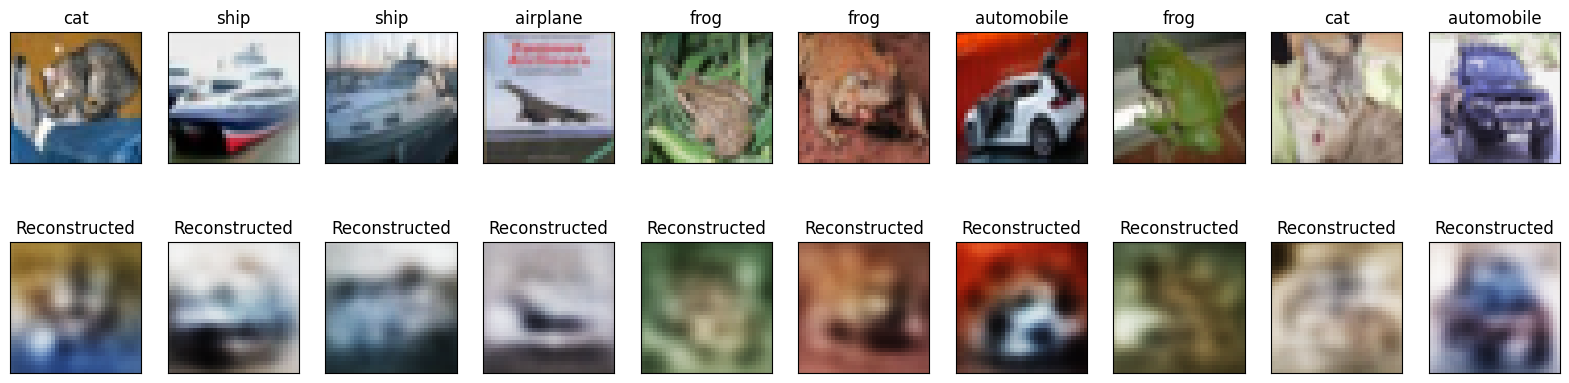

In [ ]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

n = 10
plt.figure(figsize=(20, 5))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title(classes[y_test[i][0]])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("CNN Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

print("--- Biểu đồ đối chiếu giữa Ảnh gốc và Ảnh tái tạo từ CNN ---")
plt.show()